In [1]:
from qaoa_old import * 
import networkx as nx
import matplotlib.pyplot as plt
from tqdm import tqdm

In [2]:

def plot_graph(graph):
    """
    Plot the graph using networkx and matplotlib.

    Args:
    - graph (list of lists): The adjacency matrix representing the graph.
    """

    G = nx.Graph()

    # Add nodes
    num_vertices = len(graph)
    for i in range(num_vertices):
        G.add_node(i + 1)

    # Add edges
    for i in range(num_vertices):
        for j in range(i + 1, num_vertices):
            if graph[i][j] == 1:
                G.add_edge(i + 1, j + 1)

    # Plot graph
    pos = nx.spring_layout(G)  # positions for all nodes
    nx.draw(G, pos, with_labels=True, node_color='skyblue', node_size=500, font_size=10)
    plt.title("Graph for Max-Cut Problem")
    plt.show()

def plot_multiple_angles_on_circle(angles_list, alpha=0.1):
    """
    Plot optimal angles as dots on a circle for betas and gammas with different colors for multiple angle arrays.

    Args:
    - angles_list (list of arrays): List of optimal angle arrays for betas and gammas.

    Returns:
    - None
    """
    num_betas = len(angles_list[0]) // 2  # Assuming all arrays have the same length
    num_runs = len(angles_list)
    fig, ax = plt.subplots(subplot_kw={'projection': 'polar'})
    ax.set_theta_zero_location('N')
    ax.set_aspect('equal')

    radius = [0.5 + 0.2*i for i in range(num_betas)]
    for angles in angles_list:
        betas = angles[:num_betas]
        gammas = angles[num_betas:]
        for i, r in enumerate(radius):
            # Plot betas with reduced transparency
            ax.plot(betas[i], r, 'bo', markersize=8, alpha=alpha)

            # Plot gammas with reduced transparency
            ax.plot(gammas[i], r, 'ro', markersize=8, alpha=alpha)

    plt.title("Optimal Angles on Circle")
    ax.set_yticks([0.5 + 0.2*i for i in range(num_betas)])
    ax.set_yticklabels([i+1 for i in range(num_betas)])
    plt.show()



In [3]:
edges = [[0, 1],
 [0, 2],
 [0, 3],
 [0, 4],
 [1, 0],
 [1, 2],
 [1, 3],
 [1, 4],
 [2, 0],
 [2, 1],
 [2, 3],
 [2, 4],
 [3, 0],
 [3, 1],
 [3, 2],
 [3, 5],
 [4, 0],
 [4, 1],
 [4, 2],
 [4, 6],
 [5, 3],
 [5, 7],
 [5, 8],
 [5, 9],
 [6, 4],
 [6, 7],
 [6, 8],
 [6, 9],
 [7, 5],
 [7, 6],
 [7, 8],
 [7, 9],
 [8, 5],
 [8, 6],
 [8, 7],
 [8, 9],
 [9, 5],
 [9, 6],
 [9, 7],
 [9, 8]]

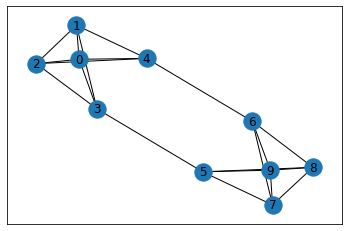

In [4]:
G = nx.from_edgelist(edges)
nx.draw_networkx(G)
adj_matrix = nx.adjacency_matrix(G).todense().tolist()
hamiltonian = Graph_to_Hamiltonian(adj_matrix)

In [5]:
angles_list = []
for i in tqdm(range(100)):
    q = QAOA(10, hamiltonian)
    q.run_heuristic_LW()
    if q.q_error < 0.1:
        angles_list.append(q.opt_angles)



100%|██████████| 100/100 [1:04:14<00:00, 38.54s/it]


In [6]:
# np.save('./angles_conc/pentas',angles_list)

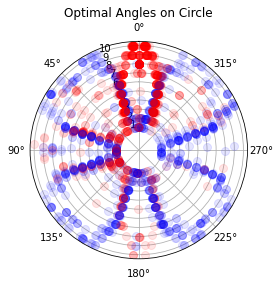

In [7]:
plot_multiple_angles_on_circle(angles_list)

In [5]:
q = QAOA(4, hamiltonian)
real_min = np.array([2,1,2,2,2,2,1,2])/8 * np.pi

In [6]:
q.expectation(real_min)

-7.999999999999994

In [67]:
q = QAOA(8, hamiltonian)

In [81]:
# q.run_heuristic_LW()
# q.run_QFI()
q.run()

In [82]:
q.log

' Depth: 8 \n Error: 0.02274745435568981 \n QAOA_Eg: -7.97725254564431 \n Exact_Eg: -8.0 \n Overlap: 0.9955151229401635 \n Exe_time: 0.12730789184570312 \n Iternations: 51'

In [51]:
def invert(angles):
    if isinstance(angles, list):
        return angles[len(angles)//2:][::-1] + angles[:len(angles)//2][::-1]
    elif isinstance(angles, np.ndarray):
        return np.concatenate((angles[len(angles)//2:][::-1], angles[:len(angles)//2][::-1]))
    else:
        raise ValueError("Unsupported data type. Expected list or ndarray.")


In [83]:
q.expectation(invert(q.opt_angles)), q.expectation((q.opt_angles)), 

(-7.3849852440863675, -7.97725254564431)

In [89]:
q = QAOA(10, hamiltonian)

In [85]:
angles_list = np.load('./angles_conc/pentas.npy')

In [88]:
angles_list[0] * 8 / np.pi

array([ 0.21530595,  4.49922246, 12.63976293,  4.69618473, 12.70016788,
       12.73695062,  0.78888865, 14.78376125,  2.16409965, 13.10407839,
        6.63561339,  3.0154276 , 15.14702368, 15.20854901, 15.22443489,
       15.31592444, 15.48041887,  0.        ,  3.68222112, 15.8733745 ])

In [95]:
test = angles_list[40] 
q.expectation(invert(test)), q.expectation((test))

(-6.456746376083873, -7.990009604223272)